In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv('iot sensor.csv')

print('=' * 60)
print(f'Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('=' * 60)

print('\nColumn Data Types:')
print(df.dtypes)

print('\nFirst 5 Rows:')
display(df.head())

Dataset Shape: 10,000 rows × 9 columns

Column Data Types:
query_id                     int64
sensor_type                 object
data_size_bytes              int64
quantity                     int64
duration                     int64
energy_consumption         float64
data_yield                 float64
hypervolume_value          float64
transmission_efficiency    float64
dtype: object

First 5 Rows:


,query_id,sensor_type,data_size_bytes,quantity,duration,energy_consumption,data_yield,hypervolume_value,transmission_efficiency
0,1,PulseOximeter,18,12,261,0.240395,152.275251,0.933088,2.264571
1,2,PulseOximeter,18,12,375,0.228580,685.799626,0.528206,4.226011
2,3,PulseOximeter,18,12,351,0.459875,141.999097,0.986878,0.868165
3,4,BloodPressure,14,12,507,0.444216,984.907797,0.733381,3.207182
4,5,BodyTemperature,12,12,746,0.158546,953.996984,0.982816,7.927275


In [21]:
print('\nDataset Info:')
df.info()

print('\nBasic Statistics (numerical columns):')
display(df.describe().round(4))

print('\nSensor Type Distribution:')
display(df['sensor_type'].value_counts())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   query_id                 10000 non-null  int64  
 1   sensor_type              10000 non-null  object 
 2   data_size_bytes          10000 non-null  int64  
 3   quantity                 10000 non-null  int64  
 4   duration                 10000 non-null  int64  
 5   energy_consumption       10000 non-null  float64
 6   data_yield               10000 non-null  float64
 7   hypervolume_value        10000 non-null  float64
 8   transmission_efficiency  10000 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 703.3+ KB

Basic Statistics (numerical columns):


,query_id,data_size_bytes,quantity,duration,energy_consumption,data_yield,hypervolume_value,transmission_efficiency
count,10000.0000,10000.0000,10000.0,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,5000.5000,59.8057,12.0,378.8315,0.5513,552.9833,0.7501,7.3949
std,2886.8957,55.5145,0.0,302.9561,0.2575,261.5217,0.1429,12.6307
min,1.0000,12.0000,12.0,6.0000,0.1001,100.0084,0.5000,0.0816
25%,2500.7500,14.0000,12.0,80.0000,0.3287,326.0279,0.6266,1.0940
50%,5000.5000,18.0000,12.0,345.0000,0.5517,553.6789,0.7509,2.8064
75%,7500.2500,120.0000,12.0,614.0000,0.7687,779.8461,0.8724,8.5958
max,10000.0000,135.0000,12.0,1139.0000,1.0000,999.8246,1.0000,404.9015



Sensor Type Distribution:


sensor_type
BloodPressure      2042
ECG                2001
Accelerometer      1999
PulseOximeter      1993
BodyTemperature    1965
Name: count, dtype: int64

In [22]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
})

print('Missing Value Report:')
display(missing_df)

Missing Value Report:


,Missing Count,Missing %
query_id,0,0.0
sensor_type,0,0.0
data_size_bytes,0,0.0
quantity,0,0.0
duration,0,0.0
energy_consumption,0,0.0
data_yield,0,0.0
hypervolume_value,0,0.0
transmission_efficiency,0,0.0


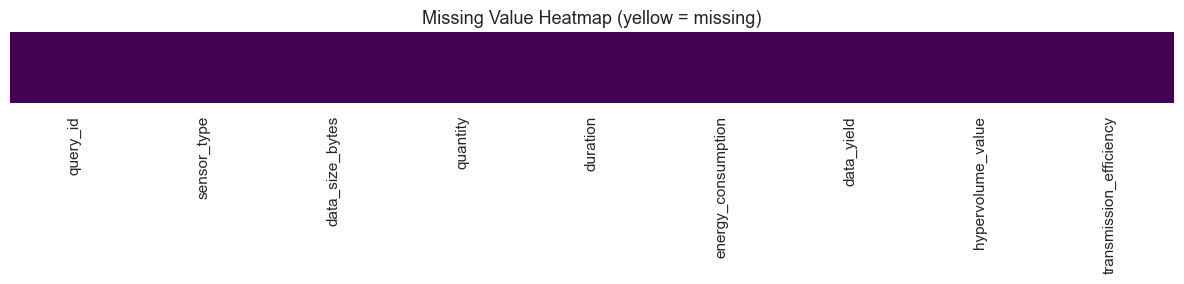


Total missing cells: 0


In [23]:
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Missing Value Heatmap (yellow = missing)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nTotal missing cells: {missing_count.sum()}')

In [24]:
outlier_report = {}

for col in num_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_report[col] = {
        'Q1': round(Q1, 4), 'Q3': round(Q3, 4), 'IQR': round(IQR, 4),
        'Lower Bound': round(lower, 4),
        'Upper Bound': round(upper, 4),
        'Outliers': n_outliers,
        'Outlier %': round(n_outliers / len(df_clean) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_report).T
print('Outlier Detection Report (IQR Method):')
display(outlier_df)

Outlier Detection Report (IQR Method):


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
data_size_bytes,14.0000,120.0000,106.0000,-145.0000,279.0000,0.0,0.00
quantity,12.0000,12.0000,0.0000,12.0000,12.0000,0.0,0.00
duration,81.0000,609.0000,528.0000,-711.0000,1401.0000,0.0,0.00
energy_consumption,0.3331,0.7639,0.4308,-0.3131,1.4101,0.0,0.00
data_yield,330.9126,775.5764,444.6638,-336.0831,1442.5721,0.0,0.00
hypervolume_value,0.6290,0.8699,0.2408,0.2678,1.2311,0.0,0.00
transmission_efficiency,1.1137,8.3910,7.2772,-9.8021,19.3068,927.0,9.27


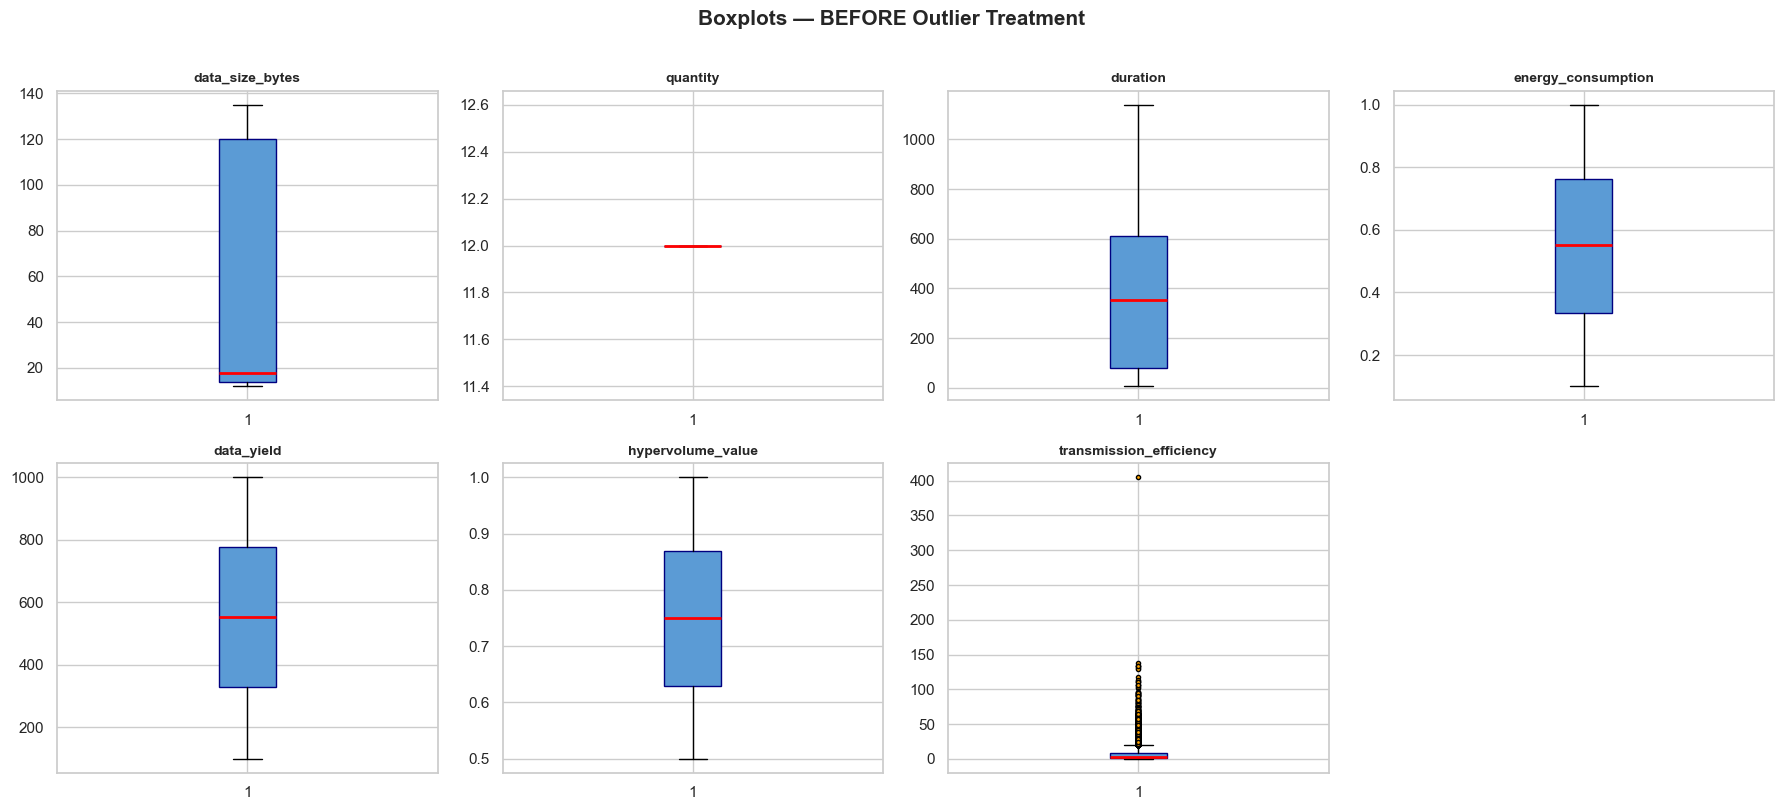

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df_clean[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#5B9BD5', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='orange',
                                   markerfacecolor='orange', markersize=3))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — BEFORE Outlier Treatment', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [26]:
df_no_outliers = df_clean.copy()

for col in num_cols:
    Q1  = df_no_outliers[col].quantile(0.25)
    Q3  = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_no_outliers[col] = df_no_outliers[col].clip(lower=lower, upper=upper)

print('Outliers capped using IQR bounds (Winsorisation).')

residual = 0
for col in num_cols:
    Q1  = df_no_outliers[col].quantile(0.25)
    Q3  = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    residual += ((df_no_outliers[col] < Q1 - 1.5*IQR) |
                 (df_no_outliers[col] > Q3 + 1.5*IQR)).sum()
print(f'Residual outliers after capping: {residual}')

Outliers capped using IQR bounds (Winsorisation).
Residual outliers after capping: 0


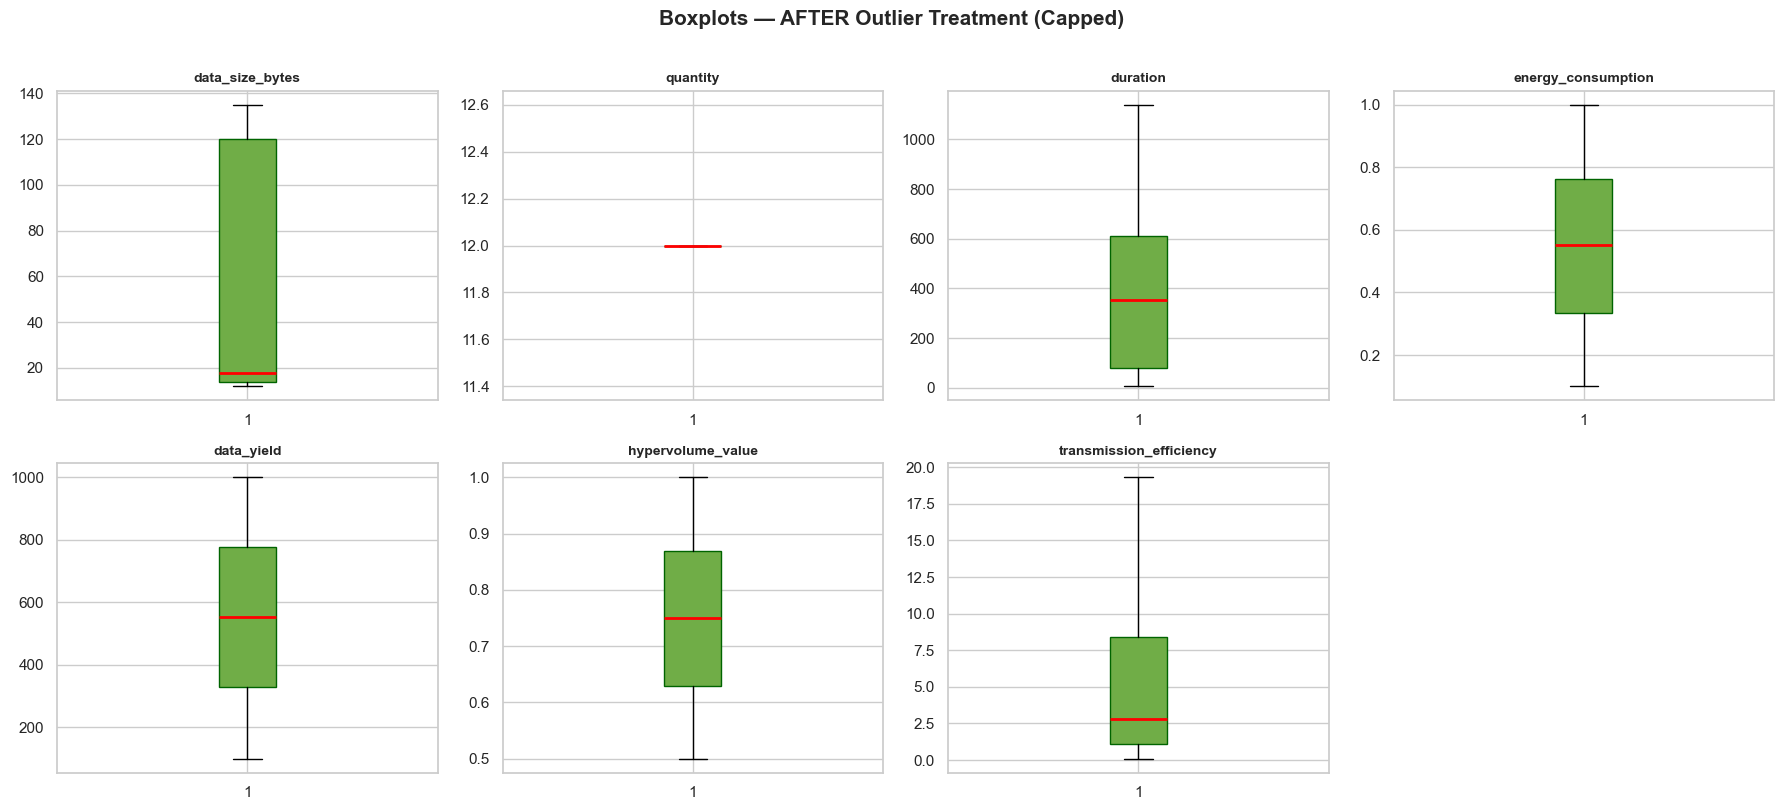

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df_no_outliers[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#70AD47', color='darkgreen'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='orange',
                                   markerfacecolor='orange', markersize=3))
    axes[i].set_title(col, fontsize=10, fontweight='bold')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — AFTER Outlier Treatment (Capped)', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [28]:
df_transformed = df_no_outliers.copy()

df_transformed['sensor_type'] = df_transformed['sensor_type'].astype('category')

int_cols = ['query_id', 'data_size_bytes', 'quantity', 'duration']
for col in int_cols:
    df_transformed[col] = pd.to_numeric(df_transformed[col], downcast='integer')

print('Updated Data Types:')
print(df_transformed.dtypes)

mem_before = df_no_outliers.memory_usage(deep=True).sum() / 1024
mem_after  = df_transformed.memory_usage(deep=True).sum() / 1024
print(f'\nMemory: {mem_before:.1f} KB → {mem_after:.1f} KB  '
      f'(saved {mem_before - mem_after:.1f} KB)')

Updated Data Types:
query_id                      int16
sensor_type                category
data_size_bytes             float64
quantity                       int8
duration                    float64
energy_consumption          float64
data_yield                  float64
hypervolume_value           float64
transmission_efficiency     float64
dtype: object

Memory: 1214.9 KB → 508.4 KB  (saved 706.5 KB)


In [29]:
from sklearn.preprocessing import MinMaxScaler

scale_cols = [c for c in num_cols if c != 'query_id']

scaler = MinMaxScaler()
df_scaled = df_transformed.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

print('Sample scaled values (first 5 rows):')
display(df_scaled[scale_cols].head().round(4))

print('\nScaled column ranges (should all be [0, 1]):')
display(df_scaled[scale_cols].agg(['min', 'max']).round(4))

Sample scaled values (first 5 rows):


,data_size_bytes,quantity,duration,energy_consumption,data_yield,hypervolume_value,transmission_efficiency
0,0.0488,0.0,0.2251,0.1559,0.0581,0.8663,0.1132
1,0.0488,0.0,0.3257,0.1427,0.6510,0.0564,0.2152
2,0.0488,0.0,0.3045,0.3998,0.0467,0.9739,0.0405
3,0.0163,0.0,0.4422,0.3824,0.9834,0.4668,0.1622
4,0.0000,0.0,0.6531,0.0649,0.9491,0.9657,0.4078



Scaled column ranges (should all be [0, 1]):


,data_size_bytes,quantity,duration,energy_consumption,data_yield,hypervolume_value,transmission_efficiency
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,0.0,1.0,1.0,1.0,1.0,1.0


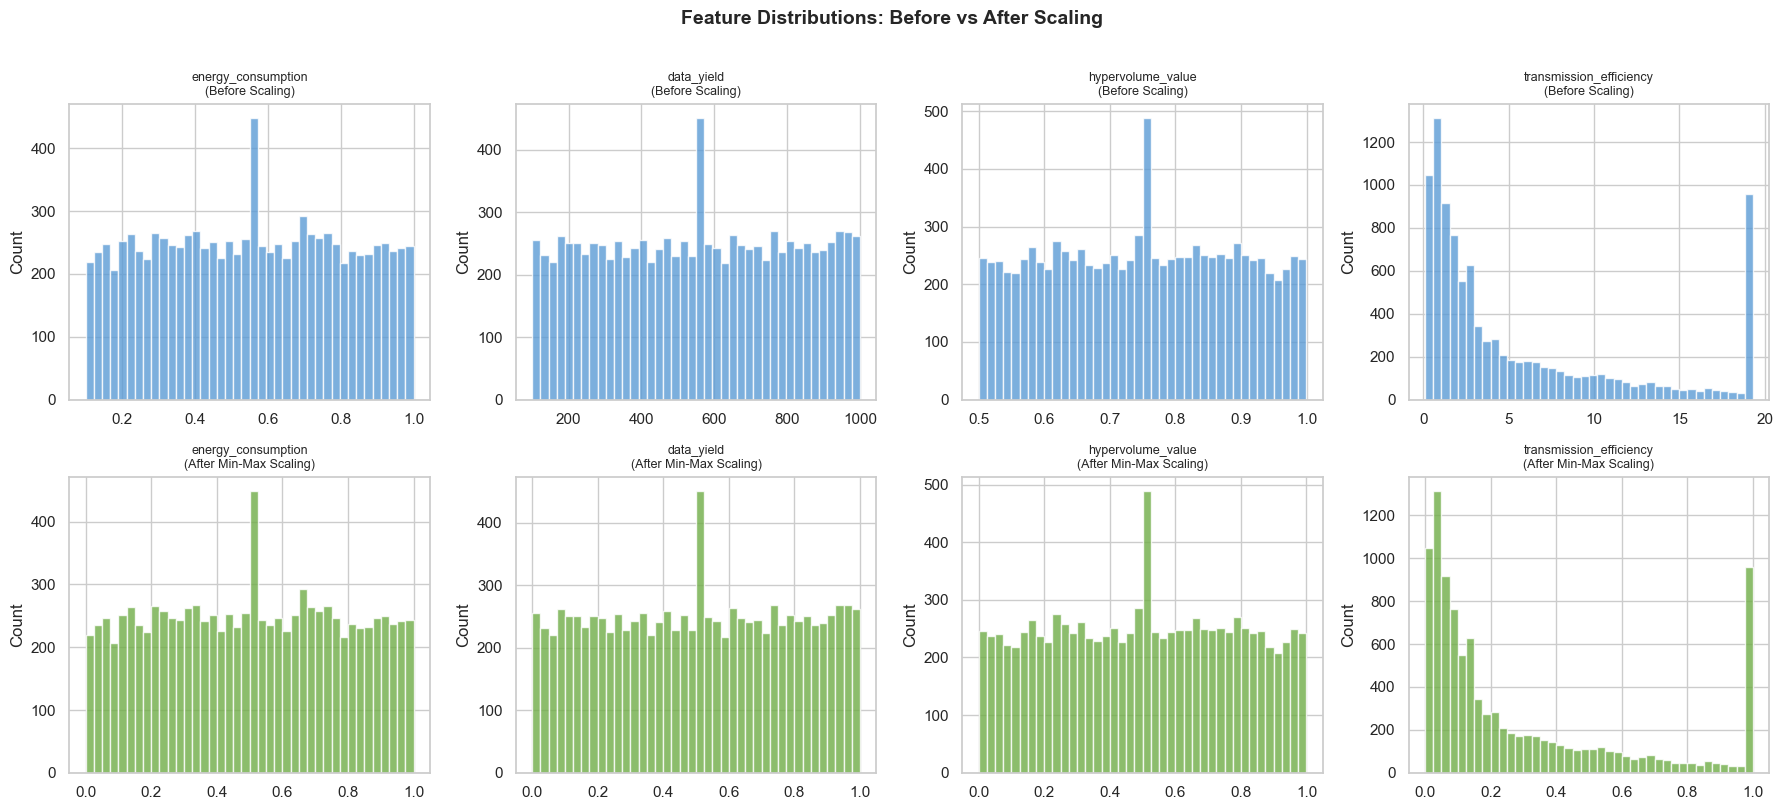

In [30]:
key_features = ['energy_consumption', 'data_yield',
                'hypervolume_value', 'transmission_efficiency']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(key_features):
    axes[0, i].hist(df_transformed[col], bins=40, color='#5B9BD5',
                    edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(Before Scaling)', fontsize=9)
    axes[0, i].set_ylabel('Count')

    axes[1, i].hist(df_scaled[col], bins=40, color='#70AD47',
                    edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(After Min-Max Scaling)', fontsize=9)
    axes[1, i].set_ylabel('Count')

plt.suptitle('Feature Distributions: Before vs After Scaling',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [31]:
print('=' * 60)
print('        DATA VALIDATION REPORT — CLEANED DATASET')
print('=' * 60)

missing_final = df_scaled.isnull().sum().sum()
print(f'\nMissing Values: {missing_final}  ', 'DONE' if missing_final == 0 else 'NOT DONE')
inf_count = np.isinf(df_scaled.select_dtypes(include=[np.number])).sum().sum()
print(f'Infinite Values: {inf_count}  ', 'DONE' if inf_count == 0 else 'NOT DONE')
dup_count = df_scaled.duplicated().sum()
print(f'Duplicate Rows: {dup_count}  ', 'DONE' if dup_count == 0 else 'NOT DONE')
range_ok = (df_scaled[scale_cols].min().min() >= 0) and \
           (df_scaled[scale_cols].max().max() <= 1)
print(f'Scaled cols in [0,1]: {range_ok}  ', 'DONE' if range_ok else 'NOT DONE')
print(f'Row count: {len(df_scaled):,} ')

print('\nFinal Summary Statistics:')
display(df_scaled.describe().round(4))

        DATA VALIDATION REPORT — CLEANED DATASET

Missing Values: 0   DONE
Infinite Values: 0   DONE
Duplicate Rows: 0   DONE
Scaled cols in [0,1]: True   DONE
Row count: 10,000 

Final Summary Statistics:


,query_id,data_size_bytes,quantity,duration,energy_consumption,data_yield,hypervolume_value,transmission_efficiency
count,10000.0000,10000.0000,10000.0,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,5000.5000,0.3886,0.0,0.3293,0.5012,0.5040,0.5002,0.2895
std,2886.8957,0.4468,0.0,0.2651,0.2833,0.2875,0.2828,0.3163
min,1.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000
25%,2500.7500,0.0163,0.0,0.0662,0.2589,0.2566,0.2581,0.0533
50%,5000.5000,0.0488,0.0,0.3071,0.5012,0.5040,0.5002,0.1416
75%,7500.2500,0.8780,0.0,0.5322,0.7377,0.7508,0.7398,0.4320
max,10000.0000,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000


In [33]:
df_scaled.to_csv('cde_ipaas_dataset_cleaned.csv', index=False)
print('Cleaned & scaled dataset saved → cde_ipaas_dataset_cleaned.csv')

df_transformed.to_csv('cde_ipaas_dataset_cleaned_unscaled.csv', index=False)
print('Cleaned & unscaled dataset saved → cde_ipaas_dataset_cleaned_unscaled.csv')

test = pd.read_csv('cde_ipaas_dataset_cleaned.csv')
print(f'\nReload check — shape: {test.shape},  missing: {test.isnull().sum().sum()}')
display(test.head(3))

Cleaned & scaled dataset saved → cde_ipaas_dataset_cleaned.csv
Cleaned & unscaled dataset saved → cde_ipaas_dataset_cleaned_unscaled.csv

Reload check — shape: (10000, 9),  missing: 0


,query_id,sensor_type,data_size_bytes,quantity,duration,energy_consumption,data_yield,hypervolume_value,transmission_efficiency
0,1,PulseOximeter,0.04878,0.0,0.225066,0.155876,0.058086,0.866255,0.113156
1,2,PulseOximeter,0.04878,0.0,0.325684,0.142746,0.651012,0.056367,0.215226
2,3,PulseOximeter,0.04878,0.0,0.304501,0.399785,0.046666,0.973851,0.040490
